<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Modeling Workflow (Walkthrough) 

---

### About
Model data from scratch: gather data, clean it, explore it, and then evaluate several models.

### Learning Objectives
- Gather, clean, explore and model a dataset from scratch.
- Split data into testing and training sets using both train/test split and cross-validation and apply both techniques to score a model.
- Evaluate several models.


### Notebook Guide

- Importing libaries
- Load the Data
- Data Cleaning:
     - Initial check
     - Clean up PhD column
     - Clean up Grad.Rate column
     - Clean up Apps column
- Stateless Feature Engineering:
     - Binarize Private column
     - Create a new feature
     - Bin Outstate column
- EDA:
     - Create Histograms of All Numerical Columns
     - Plot a Heatmap of the Correlation Matrix
     - Use seaborn's .pairplot() method to create scatterplots
     - Use seaborn's `.pairplot()` method to create scatterplots
- Model Prep:
     - Create our features matrix (`X`) and target vector (`y`)
     - Train/test split
     - Imputing Missing Values
     - Ordinal Encoding
     - Robust Scaling
     - Instantiate and train our model
- Evaluation
- LINE Assumptions

# Importing libaries
---

We'll need the following libraries for today's lesson:

1. `pandas`
2. `numpy`
3. `seaborn`
4. `matplotlib.pyplot`
4. `train_test_split` and `cross_val_score` from `sklearn`'s `model_selection` module
5. `LinearRegression` from `sklearn`'s `linear_model` module
6. `StandardScaler` from `sklearn`'s `preprocessing` module
7. `mean_squared_error` from `sklearn`'s `metrics` module 

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

# Load the Data

---

Today's [data set](http://www-bcf.usc.edu/~gareth/ISL/data.html) (`College.csv`) is from the [ISLR website](https://cran.r-project.org/web/packages/ISLR/ISLR.pdf) on page 5. 

Rename `Unnamed: 0` to `University`.

In [3]:
college_df = pd.read_csv('../data/College.csv')
college_df.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


# Data cleaning: Initial check
---

Check the following in the cells below:
1. Do we have any null values?
2. Are any numerical columns being read in as `object`?
3. Any values outside acceptable range?

In [4]:
# 1. Check for nulls
college_df.isna().sum()
# no null values detected

Unnamed: 0     0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

In [5]:
college_df.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [6]:
# 2. Check column data types
college_df.info()
# 1. private column should be boolean
# 2. PhD column format must be converted to float or int

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   777 non-null    str    
 1   Private      777 non-null    str    
 2   Apps         777 non-null    int64  
 3   Accept       777 non-null    int64  
 4   Enroll       777 non-null    int64  
 5   Top10perc    777 non-null    int64  
 6   Top25perc    777 non-null    int64  
 7   F.Undergrad  777 non-null    int64  
 8   P.Undergrad  777 non-null    int64  
 9   Outstate     777 non-null    int64  
 10  Room.Board   777 non-null    int64  
 11  Books        777 non-null    int64  
 12  Personal     777 non-null    int64  
 13  PhD          777 non-null    str    
 14  Terminal     777 non-null    int64  
 15  S.F.Ratio    777 non-null    float64
 16  perc.alumni  777 non-null    int64  
 17  Expend       777 non-null    int64  
 18  Grad.Rate    777 non-null    int64  
dtypes: float64(1), int6

In [7]:
# 3. Check summary statistics
# numeric columns
college_df.select_dtypes(include='number').describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [8]:
# 
college_df.select_dtypes(include='object').describe()

C:\Users\TALAL ALOTHMAN\AppData\Local\Temp\ipykernel_12528\1388046859.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  college_df.select_dtypes(include='object').describe()


,Unnamed: 0,Private,PhD
count,777,777,777
unique,777,2,78
top,Abilene Christian University,Yes,?
freq,1,565,29


# Data cleaning: Clean up `PhD` column
---

`PhD` is being read in as a string because some of the cells contain non-numerical values. 

In the cell below:
1. replace any non-numerical values with `NaN`'s
2. change the column datatype to float
3. Verify the number of missing values

In [9]:
college_df['PhD'][college_df['PhD'] == '?'].value_counts()

PhD
?    29
Name: count, dtype: int64

In [10]:
# 1. replace non-numerical values with 'nan' or null 
college_df['PhD'] = college_df['PhD'].replace(to_replace='?', value='NaN', inplace=True)
college_df['PhD'].isnull().sum()

C:\Users\TALAL ALOTHMAN\AppData\Local\Temp\ipykernel_12528\3247312165.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  college_df['PhD'] = college_df['PhD'].replace(to_replace='?', value='NaN', inplace=True)


np.int64(0)

In [11]:
# 2. Change column datatype to float
college_df['PhD'] = college_df['PhD'].astype(float)

college_df['PhD'].dtype

dtype('float64')

In [12]:
# 3. verify the number of missing values
college_df['PhD'].isna().sum()

# 29 missing values in 'PhD' column

np.int64(29)

`PhD` should now contain missing values.

1. Suggest a strategy to deal with it.

**NOTE**: If you decide to substitute with plausible values, DO NOT APPLY IT YET HERE.

In [13]:
# Your suggestions

# my suggestion is to see the histogram & statistical variables to decide the nature of the data
# Case 1: if it's normally distributed, fill missing values with the mean
# Case 2: if it isn't normally distributed, fill missing values with the median 

<Axes: xlabel='PhD', ylabel='Count'>

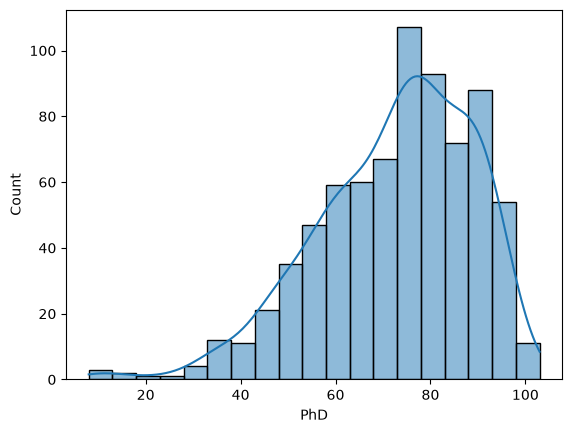

In [14]:
sns.histplot(data=college_df['PhD'],
             kde=True
             )

We weren't able to describe `PhD` using summary statistics as its type was `object`

1. Apply `.describe()` to the column
2. Any values out of normal range?
3. Suggest a strategy to fix the errors, if any.

In [15]:
# 1.
college_df['PhD'].describe()
# the data could be normally distributed since the difference between mean & median is reletavely small (difference is 2.5)

count    748.000000
mean      72.518717
std       16.315199
min        8.000000
25%       62.000000
50%       75.000000
75%       85.000000
max      103.000000
Name: PhD, dtype: float64

In [16]:
# 2. 

# 'PhD' column is the percent of faculty members with PhD's degree
# it cannot be beyond 100, but in the data we have 103% !!!!



In [ ]:
# 3. 
dckdsm



# Data cleaning: Clean up `Grad.Rate` column
---

`Grad.Rate` is the graduation rate, but it has data entry errors.

1. Suggest a strategy to fix the errors and apply it

_HINT: check the rows where the errors take place_

In [27]:
college_df.info()
college_df['Grad.Rate'][college_df['Grad.Rate'] > 100].index

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   777 non-null    str    
 1   Private      777 non-null    str    
 2   Apps         777 non-null    int64  
 3   Accept       777 non-null    int64  
 4   Enroll       777 non-null    int64  
 5   Top10perc    777 non-null    int64  
 6   Top25perc    777 non-null    int64  
 7   F.Undergrad  777 non-null    int64  
 8   P.Undergrad  777 non-null    int64  
 9   Outstate     777 non-null    int64  
 10  Room.Board   777 non-null    int64  
 11  Books        777 non-null    int64  
 12  Personal     777 non-null    int64  
 13  PhD          748 non-null    float64
 14  Terminal     777 non-null    int64  
 15  S.F.Ratio    777 non-null    float64
 16  perc.alumni  777 non-null    int64  
 17  Expend       777 non-null    int64  
 18  Grad.Rate    777 non-null    int64  
dtypes: float64(2), int6

RangeIndex(start=95, stop=96, step=1)

# Data cleaning: Clean up `Apps` column
---

1. Are there any outliers in the `Apps` column? Can you safely remove any?

# Stateless Feature Engineering: Binarize `Private` column
---

In the cells below, convert the `Private` column into numerical values.

# Stateless Feature Engineering: Create a new feature 
---

An acceptance rate is more meaningful than the counts of applicants and accepted students on their own. It represents the proportion of applicants who were accepted.

1. Create a new feature `Accept.Rate` and save it back to our dataframe

# Stateless Feature Engineering: Bin `Outstate ` column
---

1. Create a new column `Outstate.Tier` to split out-of-state tuition into bins. Use the following thresholds:
- 0 - 8,000: Low
- 8,000 - 12,000: Medium
- 12,000 - 16,000: High
- 16,000 and up: Very High



# EDA: Create Histograms of All Numerical Columns
---

1. Which features would you apply a standard scaling? Robust scaling?
2. Which features would you apply Log Transformation?

# EDA: Plot a Heatmap of the Correlation Matrix
---

Heatmaps are an effective way to visually examine the correlational structure of your predictors. 

1. Plot a heatmap
2. What features are highly correlated with each other? (use >=0.8 threshold value)
3. Any features leading to future/target-related leakage ?
4. Make a list of other features you recommend to drop based on the correlation value.

**NOTE**: Don't drop any column now, just make a list of features you plan not to use.

In [ ]:
# 1.


In [ ]:
# 2. 


In [ ]:
# 3. 



In [ ]:
# 4.


##### What if I just wanted to look at the correlation to `apps`?

# EDA: Use seaborn's `.pairplot()` method to create scatterplots 
---

1. Let's create a pairplot to see how some of our stronger predictors correlate to our target (`apps`). 
**HINT**: Instead of creating a pairplot of the entire DataFrame, we can use the `y_vars` and `x_vars` params to get a smaller subset.

2. Do you seen any linear relation between features and target? What transformation you recomment here?

In [ ]:
# 1.


In [ ]:
# 2. 


# Model_1 Prep: Create our features matrix (`X`) and target vector (`y`)
---

What should our features be?

The `apps` column is our label: the number of applications received by that university.

In the cell below, create your `X` and `y` variables.

In [ ]:
X = 
y = 

SyntaxError: invalid syntax (3877765964.py, line 1)

# Model_1 Prep: Train/test split
---

We always want to have a holdout set to test our model. Use the `train_test_split` function to split our `X` and `y` variables into a training set and a holdout set.

**HINT**: We have less than 1000 samples. Think of a suitable test size

# Model_1 Prep: Imputing Missing Values
---

Some machine learning models cannot work with missing values (`NaN`), so we need to replace them before training.

An **imputer** fills missing values using a value learned from the data. For numerical features, a common approach is to replace missing values with the **mean** or **median**.

⚠️ **Why do we impute after the train/test split?**

The median/mean is calculated from the data. If we calculate it using the full dataset, information from the test set would leak into the training process.

Therefore:

- Fit the imputer using **`X_train` only**
- Use that same imputer to transform both **`X_train` and `X_test`**

Check this [doc](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) for more details

In the cell below:

1. Identify the numerical features containing missing values. Save them in a list
2. Instantiate a `SimpleImputer` using `strategy="median"`.
3. Fit the imputer on the training features containing missing values.
4. Transform both the training and test data ( Save the results back to **`X_train` and `X_test`**)

In [ ]:
# 1. 

cols_impute = [ ]

In [ ]:
# 2.


In [ ]:
# 3.


In [ ]:
# 4.

X_train[cols_impute] = 

X_test[cols_impute] = 

# Model_1 Prep: Ordinal Encoding
---

In the cell below:

1. Identify the ordinal categorical features. Save them in a list
2. Instantiate the appropriate transformer
3. Fit the transformer on the training features containing missing values.
4. Transform both the training and test data ( Save the results back to **`X_train` and `X_test`**)

In [ ]:
# 1.

cols_ordinal = [ ]

In [ ]:
# 2.



In [ ]:
# 3.


In [ ]:
# 4.

X_train[cols_ordinal] = 

X_test[cols_ordinal] = 

# Model_1 Prep: Robust Scaling
---

In the cell below:
1. Select the features to scale. Save them in a variable
2. Fit a `RobustScaler` to `X_train` and 
3. Use it to transform both `X_train` and `X_test`. 

**NOTE**: In real projects, we usually apply different scales based on the data distribution. For the sake of practice, we are just choosing one for all features

In [ ]:
# 1.
cls_num = 

In [ ]:
# 2. 


In [ ]:
# 3.
X_train[cls_num] = 

X_test[cls_num] = 

# Model_1 Prep: Instantiate and train our model
---


In [ ]:
lr_model = 

# Model_1 Evaluation
---

Use `MAE` to evaluate the model.

1. Calculate the training MAE
2. Calculate the testing MAE
3. Do you think we are overfitting, underfitting?

In [ ]:
# 1. 

 

In [ ]:
# 2.



In [ ]:
# 3.  



# Model_1 LINE Assumptions
---

1. Check the distribution of your errors
2. Check the equality of variace for your error

In [ ]:
# N - Normality of errors


In [ ]:
# E - Equal variance of errors


> Variance of the dependent variable varies and is not constant across the entire dataset.

# Model_2 Recommendations
---

We could now apply power transformations for the extremely skewed features/target and test if we get better results.

We will come back to this notebook after we introduce pipelines